In [8]:
 import pandas as pd

df = pd.read_csv('/Users/kesh/Desktop/Project 4 hr-attrition-analysis/Data/hr_attrition_raw.csv')
df.shape

(1470, 35)

In [9]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate EmployeeNumbers:", df['EmployeeNumber'].duplicated().sum())

Duplicate rows: 0
Duplicate EmployeeNumbers: 0


In [12]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "→", df[col].unique())

EmployeeCount → [1]
Over18 → <StringArray>
['Y']
Length: 1, dtype: str
StandardHours → [80]


In [13]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours']
df_clean = df.drop(columns=drop_cols)
df_clean.shape

(1470, 32)

In [17]:
import sqlite3

conn = sqlite3.connect('../Data/hr_attrition.db')
df_clean.to_sql('employees', conn, if_exists='replace', index=False)

pd.read_sql("SELECT COUNT(*) AS row_count FROM employees", conn)

,row_count
0,1470


In [18]:
attrition_rate = pd.read_sql('''
    SELECT Attrition, 
           COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM employees), 1) AS pct
    FROM employees
    GROUP BY Attrition
''', conn)
attrition_rate

,Attrition,n,pct
0,No,1233,83.9
1,Yes,237,16.1


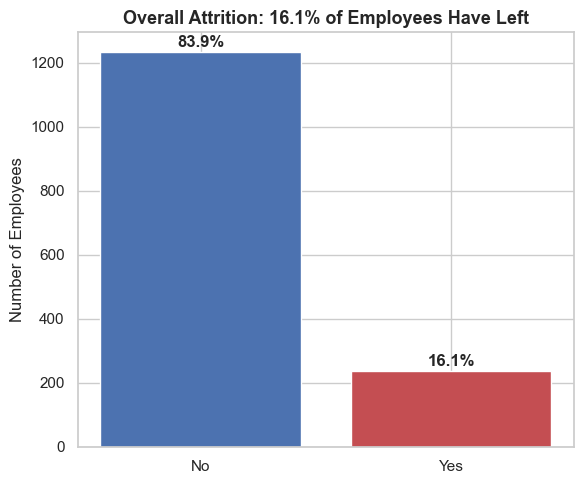

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6,5))
colors = ['#4C72B0', '#C44E52']
ax.bar(attrition_rate['Attrition'], attrition_rate['n'], color=colors)

for i, row in attrition_rate.iterrows():
    ax.text(i, row['n'] + 15, f"{row['pct']}%", ha='center', fontweight='bold')

ax.set_title('Overall Attrition: 16.1% of Employees Have Left', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('../Output/01_overall_attrition.png', dpi=150)
plt.show()

In [20]:
dept_attrition = pd.read_sql('''
    SELECT Department,
           COUNT(*) AS total,
           SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS left_count,
           ROUND(100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS attrition_pct
    FROM employees
    GROUP BY Department
    ORDER BY attrition_pct DESC
''', conn)
dept_attrition

,Department,total,left_count,attrition_pct
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research & Development,961,133,13.8


In [21]:
role_attrition = pd.read_sql('''
    SELECT JobRole,
           COUNT(*) AS total,
           SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS left_count,
           ROUND(100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS attrition_pct
    FROM employees
    GROUP BY JobRole
    HAVING total >= 20
    ORDER BY attrition_pct DESC
''', conn)
role_attrition

,JobRole,total,left_count,attrition_pct
0,Sales Representative,83,33,39.8
1,Laboratory Technician,259,62,23.9
2,Human Resources,52,12,23.1
3,Sales Executive,326,57,17.5
4,Research Scientist,292,47,16.1
5,Manufacturing Director,145,10,6.9
6,Healthcare Representative,131,9,6.9
7,Manager,102,5,4.9
8,Research Director,80,2,2.5


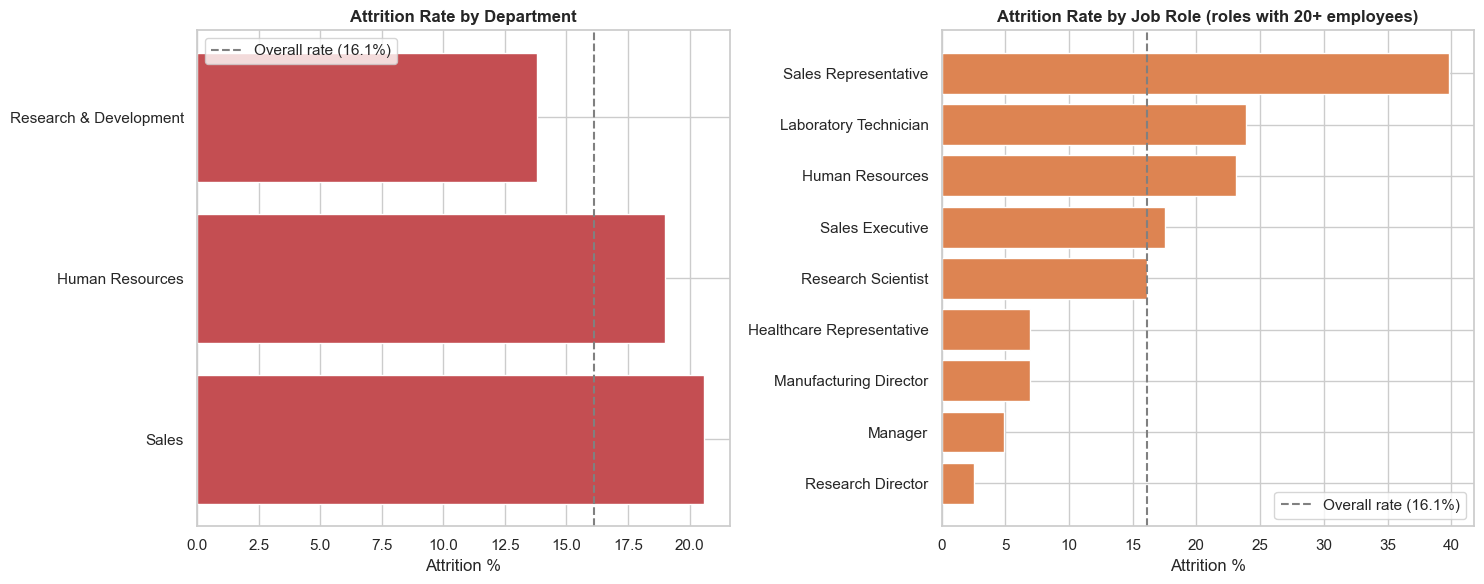

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].barh(dept_attrition['Department'], dept_attrition['attrition_pct'], color='#C44E52')
axes[0].axvline(16.1, color='gray', linestyle='--', label='Overall rate (16.1%)')
axes[0].set_title('Attrition Rate by Department', fontweight='bold')
axes[0].set_xlabel('Attrition %')
axes[0].legend()

role_sorted = role_attrition.sort_values('attrition_pct')
axes[1].barh(role_sorted['JobRole'], role_sorted['attrition_pct'], color='#DD8452')
axes[1].axvline(16.1, color='gray', linestyle='--', label='Overall rate (16.1%)')
axes[1].set_title('Attrition Rate by Job Role (roles with 20+ employees)', fontweight='bold')
axes[1].set_xlabel('Attrition %')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Output/02_department_role_attrition.png', dpi=150)
plt.show()

In [23]:
tenure_attrition = pd.read_sql('''
    SELECT 
        CASE 
            WHEN YearsAtCompany <= 2 THEN '0-2 yrs'
            WHEN YearsAtCompany <= 5 THEN '3-5 yrs'
            WHEN YearsAtCompany <= 10 THEN '6-10 yrs'
            ELSE '10+ yrs'
        END AS tenure_band,
        COUNT(*) AS total,
        ROUND(100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS attrition_pct
    FROM employees
    GROUP BY tenure_band
''', conn)
tenure_attrition

,tenure_band,total,attrition_pct
0,0-2 yrs,342,29.8
1,10+ yrs,246,8.1
2,3-5 yrs,434,13.8
3,6-10 yrs,448,12.3


In [24]:
band_order = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
tenure_attrition['tenure_band'] = pd.Categorical(tenure_attrition['tenure_band'], categories=band_order, ordered=True)
tenure_attrition = tenure_attrition.sort_values('tenure_band')
tenure_attrition

,tenure_band,total,attrition_pct
0,0-2 yrs,342,29.8
2,3-5 yrs,434,13.8
3,6-10 yrs,448,12.3
1,10+ yrs,246,8.1


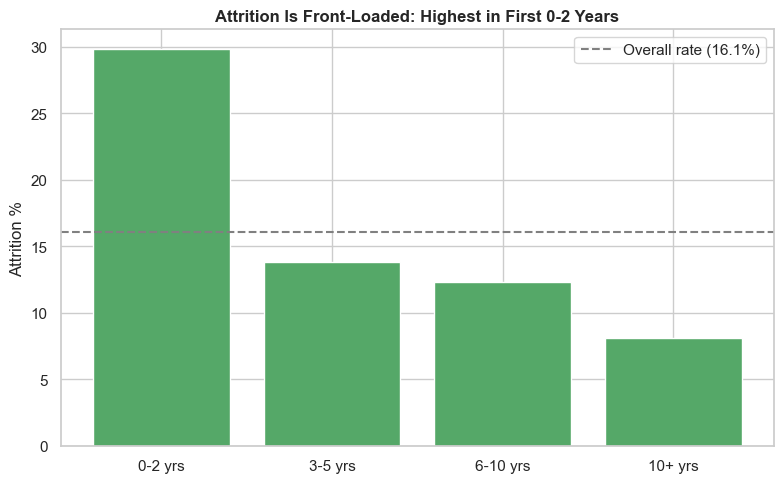

In [25]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(tenure_attrition['tenure_band'], tenure_attrition['attrition_pct'], color='#55A868')
ax.axhline(16.1, color='gray', linestyle='--', label='Overall rate (16.1%)')
ax.set_title('Attrition Is Front-Loaded: Highest in First 0-2 Years', fontweight='bold')
ax.set_ylabel('Attrition %')
ax.legend()
plt.tight_layout()
plt.savefig('../Output/03_tenure_attrition.png', dpi=150)
plt.show()

In [26]:
overtime_attrition = pd.read_sql('''
    SELECT OverTime, 
           COUNT(*) AS total,
           ROUND(100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS attrition_pct
    FROM employees
    GROUP BY OverTime
''', conn)
overtime_attrition

,OverTime,total,attrition_pct
0,No,1054,10.4
1,Yes,416,30.5


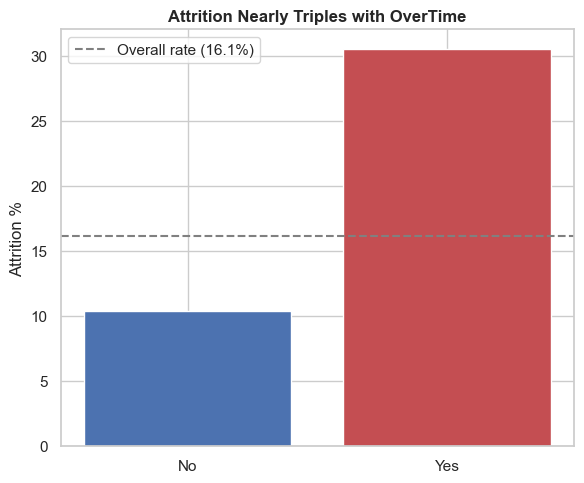

In [27]:
fig, ax = plt.subplots(figsize=(6,5))
ax.bar(overtime_attrition['OverTime'], overtime_attrition['attrition_pct'], color=['#4C72B0','#C44E52'])
ax.axhline(16.1, color='gray', linestyle='--', label='Overall rate (16.1%)')
ax.set_title('Attrition Nearly Triples with OverTime', fontweight='bold')
ax.set_ylabel('Attrition %')
ax.legend()
plt.tight_layout()
plt.savefig('../Output/04_overtime_attrition.png', dpi=150)
plt.show()

In [28]:
df_encoded = df_clean.copy()
df_encoded['Attrition_flag'] = (df_encoded['Attrition'] == 'Yes').astype(int)

numeric_cols = df_encoded.select_dtypes(include=['number']).columns.tolist()
corr_with_attrition = df_encoded[numeric_cols].corr()['Attrition_flag'].drop('Attrition_flag').sort_values()

corr_with_attrition

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Name: Attrition_flag, dtype: float64

# Summary of Findings

Overall attrition rate is 16.1% — roughly 1 in 6 employees have left. This is the baseline every other segment below is measured against.

Sales and HR run above that baseline (20.6% and 19.0% respectively), while R&D — despite being the largest department by far — runs below it at 13.8%.

The department view understates the real problem. At the role level, Sales Representatives leave at 39.8%, nearly 2.5x the company average, making it the single highest-risk role in the dataset. Laboratory Technicians (23.9%) and HR (23.1%) follow.

Attrition is heavily front-loaded by tenure. Employees in their first 0-2 years leave at 29.8%, compared to just 8.1% for employees with 10+ years. Risk drops steadily and consistently the longer someone stays.
OverTime is the strongest behavioral signal in the dataset — employees working overtime leave at 30.5%, nearly triple the rate of those who don't (10.4%).

No single factor dominates in the correlation analysis — tenure-related measures (YearsAtCompany, TotalWorkingYears, JobLevel, MonthlyIncome) cluster together as the next-strongest signals, but none exceed a weak-to-moderate correlation on their own, suggesting attrition here is driven by a combination of overlapping factors rather than one root cause.

## Suggested retention priorities based on this data: 

Focus onboarding and early-career support on the 0-2 year window, investigate workload and overtime policy specifically within Sales and HR, and treat compensation as a secondary lever rather than the primary fix.

In [29]:
df_clean.to_csv('../Data/hr_attrition_clean.csv', index=False)
print("Exported:", df_clean.shape)

Exported: (1470, 32)
